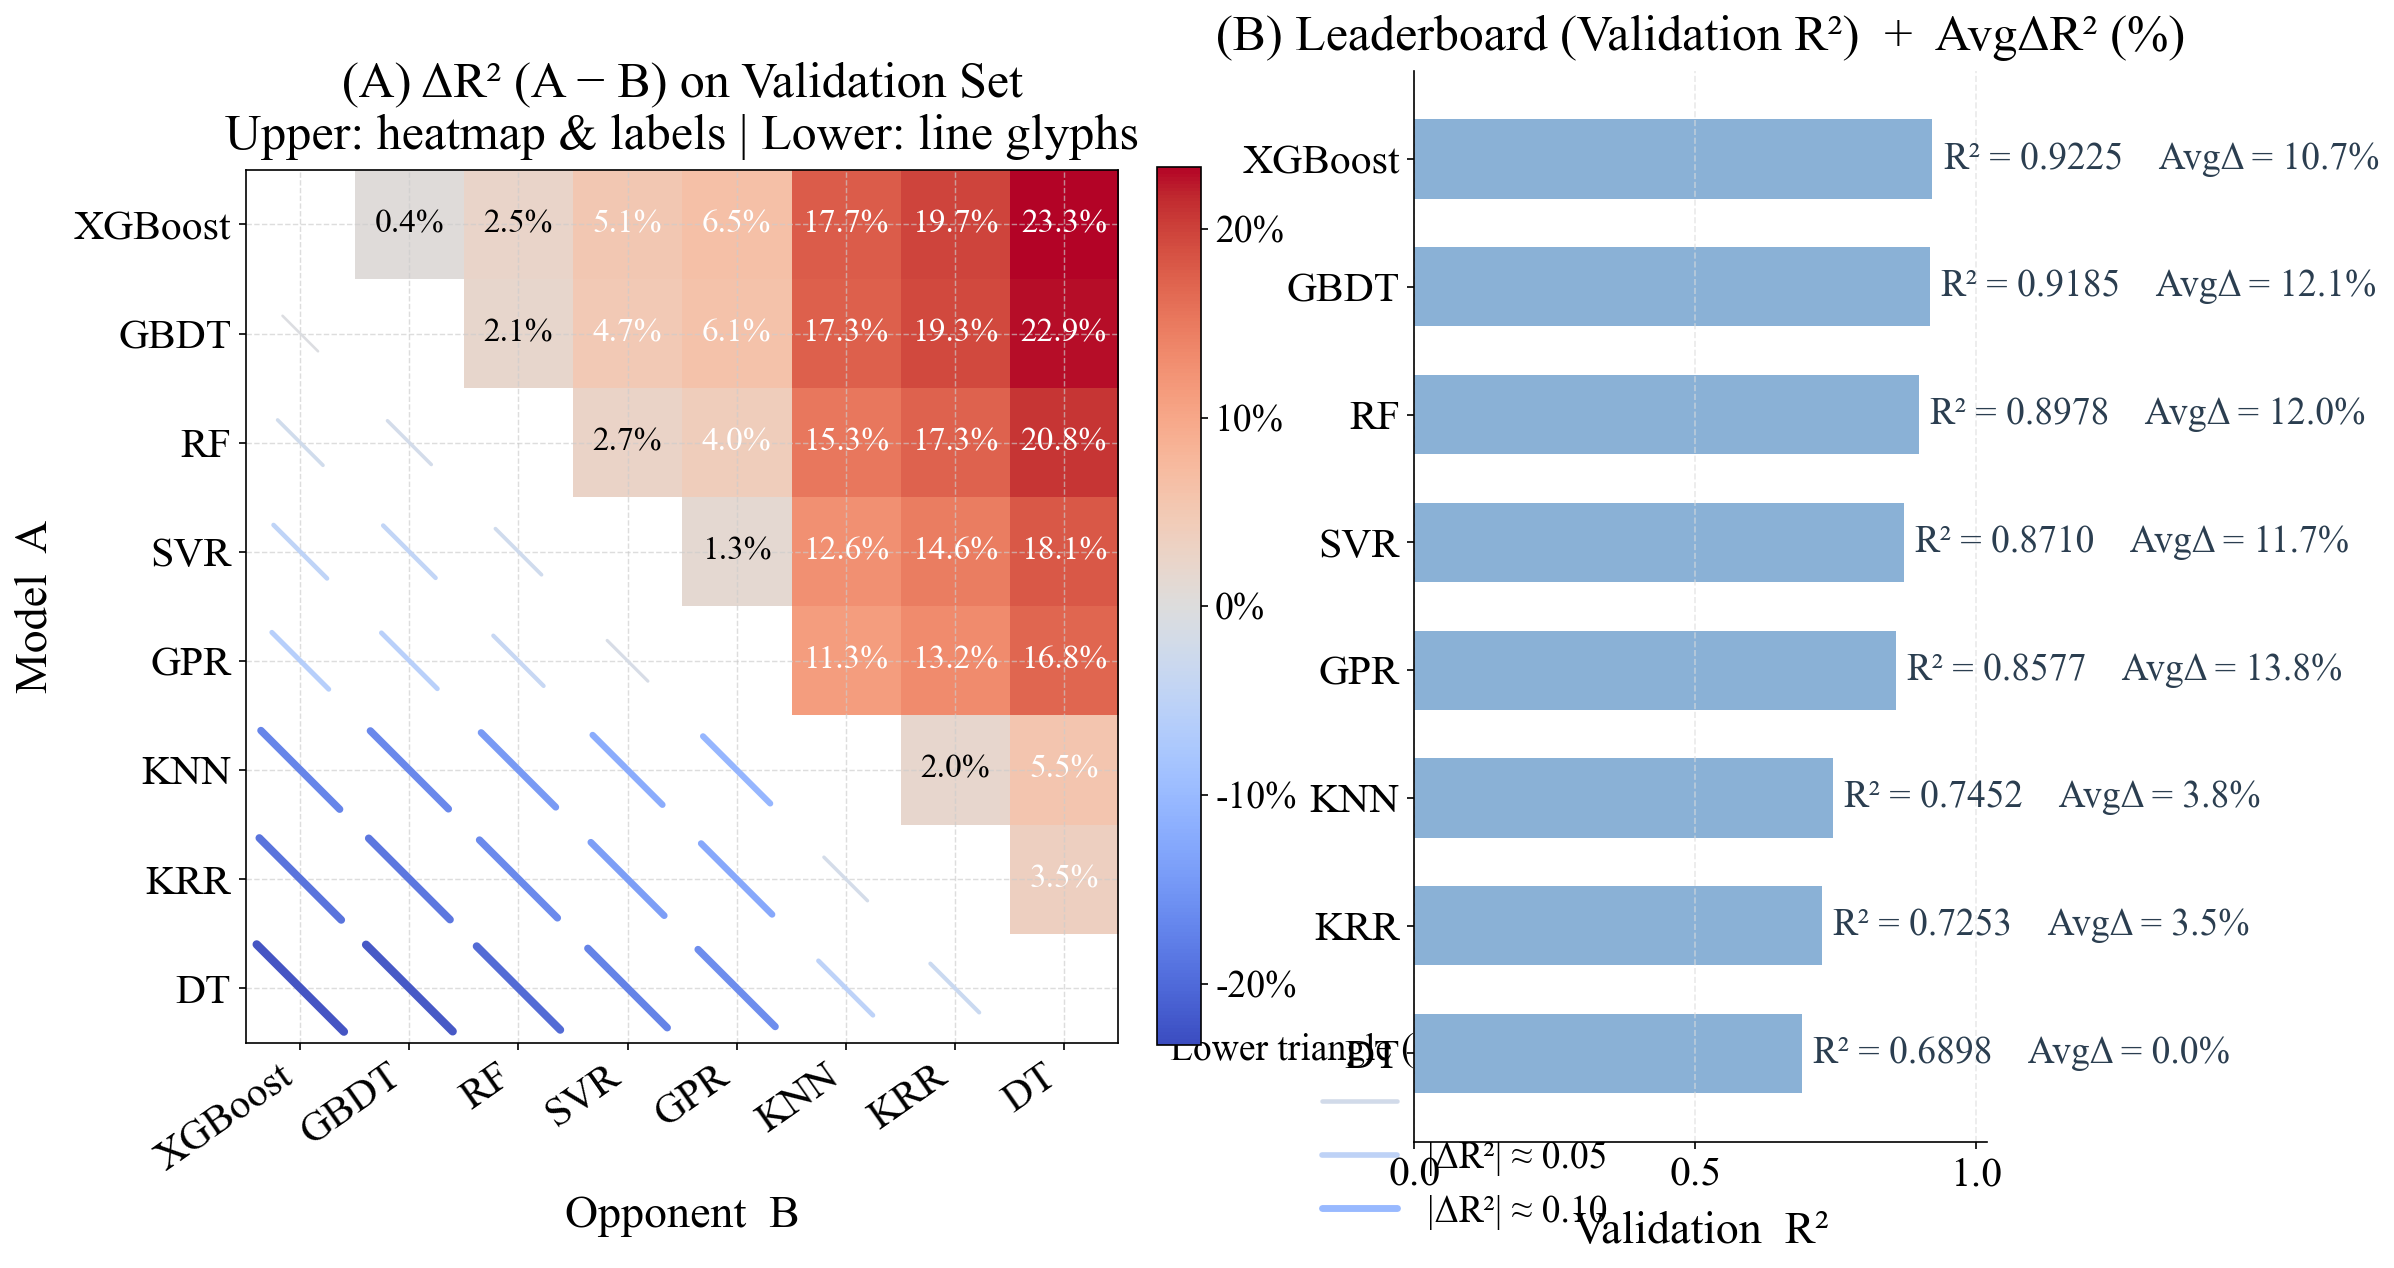

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

data = [
    ("XGBoost", 0.9225),
    ("GBDT",    0.9185),
    ("RF",      0.8978),
    ("SVR",     0.8710),
    ("GPR",     0.8577),
    ("KNN",     0.7452),
    ("KRR",     0.7253),
    ("DT",      0.6898),
]
df = pd.DataFrame(data, columns=["Model", "R2_val"])

df = df.sort_values("R2_val", ascending=False).reset_index(drop=True)
models = df["Model"].tolist()
r2 = df["R2_val"].to_numpy()

delta = r2[:, None] - r2[None, :]
np.fill_diagonal(delta, np.nan)

wins = (delta > 0).astype(int)
np.fill_diagonal(wins, 0)
row_wins = wins.sum(axis=1)

avg_margin = np.zeros_like(row_wins, dtype=float)
positive_delta = np.where(delta > 0, delta, np.nan)
valid_mask = row_wins > 0
avg_margin[valid_mask] = np.nansum(positive_delta, axis=1)[valid_mask] / row_wins[valid_mask]

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 400,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 16,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

fig = plt.figure(figsize=(13.5, 8.5))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[7.5, 4.5], wspace=0.28)

ax = fig.add_subplot(gs[0, 0])

vmax = np.nanmax(np.abs(delta))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
cmap = plt.colormaps["coolwarm"].copy()
cmap.set_bad((0, 0, 0, 0))

mask_lower = np.tril(np.ones_like(delta, dtype=bool), k=0)
delta_upper = np.ma.array(delta, mask=mask_lower)

im = ax.imshow(delta_upper, cmap=cmap, norm=norm)

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=35, ha="right")
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models)
ax.set_xlabel("Opponent  B", labelpad=8)
ax.set_ylabel("Model  A", labelpad=8)
ax.set_title("(A) ΔR² (A − B) on Validation Set\nUpper: heatmap & labels | Lower: line glyphs", pad=10)

for i in range(len(models)):
    for j in range(len(models)):
        if not (i < j):
            continue
        val = delta[i, j]
        if np.isnan(val):
            continue
        txt = f"{val*100:.1f}%"
        color = "white" if abs(val) > 0.15 * vmax else "black"
        ax.text(j, i, txt, ha="center", va="center", color=color, fontsize=16)

def draw_lower_triangle_glyphs(ax, delta, norm, cmap):
    n = delta.shape[0]
    max_len = 0.40
    for i in range(n):
        for j in range(n):
            if not (i > j):
                continue
            val = delta[i, j]
            if np.isnan(val):
                continue
            mag = abs(val)
            if mag == 0:
                continue
            scale = min(1.0, (mag / vmax) ** 0.6)
            L = max_len * (0.35 + 0.65 * scale)
            lw = 1.0 + 3.0 * scale
            color = cmap(norm(val))

            cx, cy = j, i
            if val > 0:
                x0, y0 = cx - L, cy + L
                x1, y1 = cx + L, cy - L
            else:
                x0, y0 = cx - L, cy - L
                x1, y1 = cx + L, cy + L

            ax.plot([x0, x1], [y0, y1],
                    color=color, linewidth=lw, solid_capstyle="round", alpha=0.95)

draw_lower_triangle_glyphs(ax, delta, norm, cmap)

ax.set_xlim(-0.5, len(models) - 0.5)
ax.set_ylim(len(models) - 0.5, -0.5)
ax.grid(color="#cccccc", linestyle="--", linewidth=0.7, alpha=0.65)
ax.set_axisbelow(True)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
cbar.ax.tick_params(labelsize=18)

mag_bins = [0.02, 0.05, 0.10]
proxies = [
    Line2D([0, 1], [0, 0],
           color=cmap(norm(-b)),
           linewidth=1.5 + 3.0 * ((b / vmax) ** 0.6),
           solid_capstyle="round")
    for b in mag_bins
]
ax.legend(
    proxies,
    [f"|ΔR²| ≈ {b:.02f}" for b in mag_bins],
    title="Lower triangle (A < B): line magnitude",
    loc="upper left", bbox_to_anchor=(1.02, 0.05),
    frameon=False, fontsize=18, title_fontsize=18
)

axr = fig.add_subplot(gs[0, 1])
ypos = np.arange(len(models))
axr.barh(ypos, r2, color="#7aa6d1", alpha=0.88, height=0.62)
axr.set_yticks(ypos)
axr.set_yticklabels(models)
axr.invert_yaxis()
axr.set_xlim(0, max(1.02, r2.max() * 1.08))
axr.set_xlabel("Validation  R²", labelpad=8)
axr.set_title("(B) Leaderboard (Validation R²)  +  AvgΔR² (%)", pad=10)

for i, (r, m) in enumerate(zip(r2, avg_margin)):
    axr.text(r + 0.02, i,
             f"R² = {r:.4f}    AvgΔ = {m*100:.1f}%",
             va="center", fontsize=18, color="#2b3e50")

for spine in ["top", "right"]:
    axr.spines[spine].set_visible(False)
axr.grid(axis="x", color="#dddddd", linestyle="--", alpha=0.6)

plt.subplots_adjust(left=0.06, right=0.92, top=0.92, bottom=0.08, wspace=0.28)
plt.show()

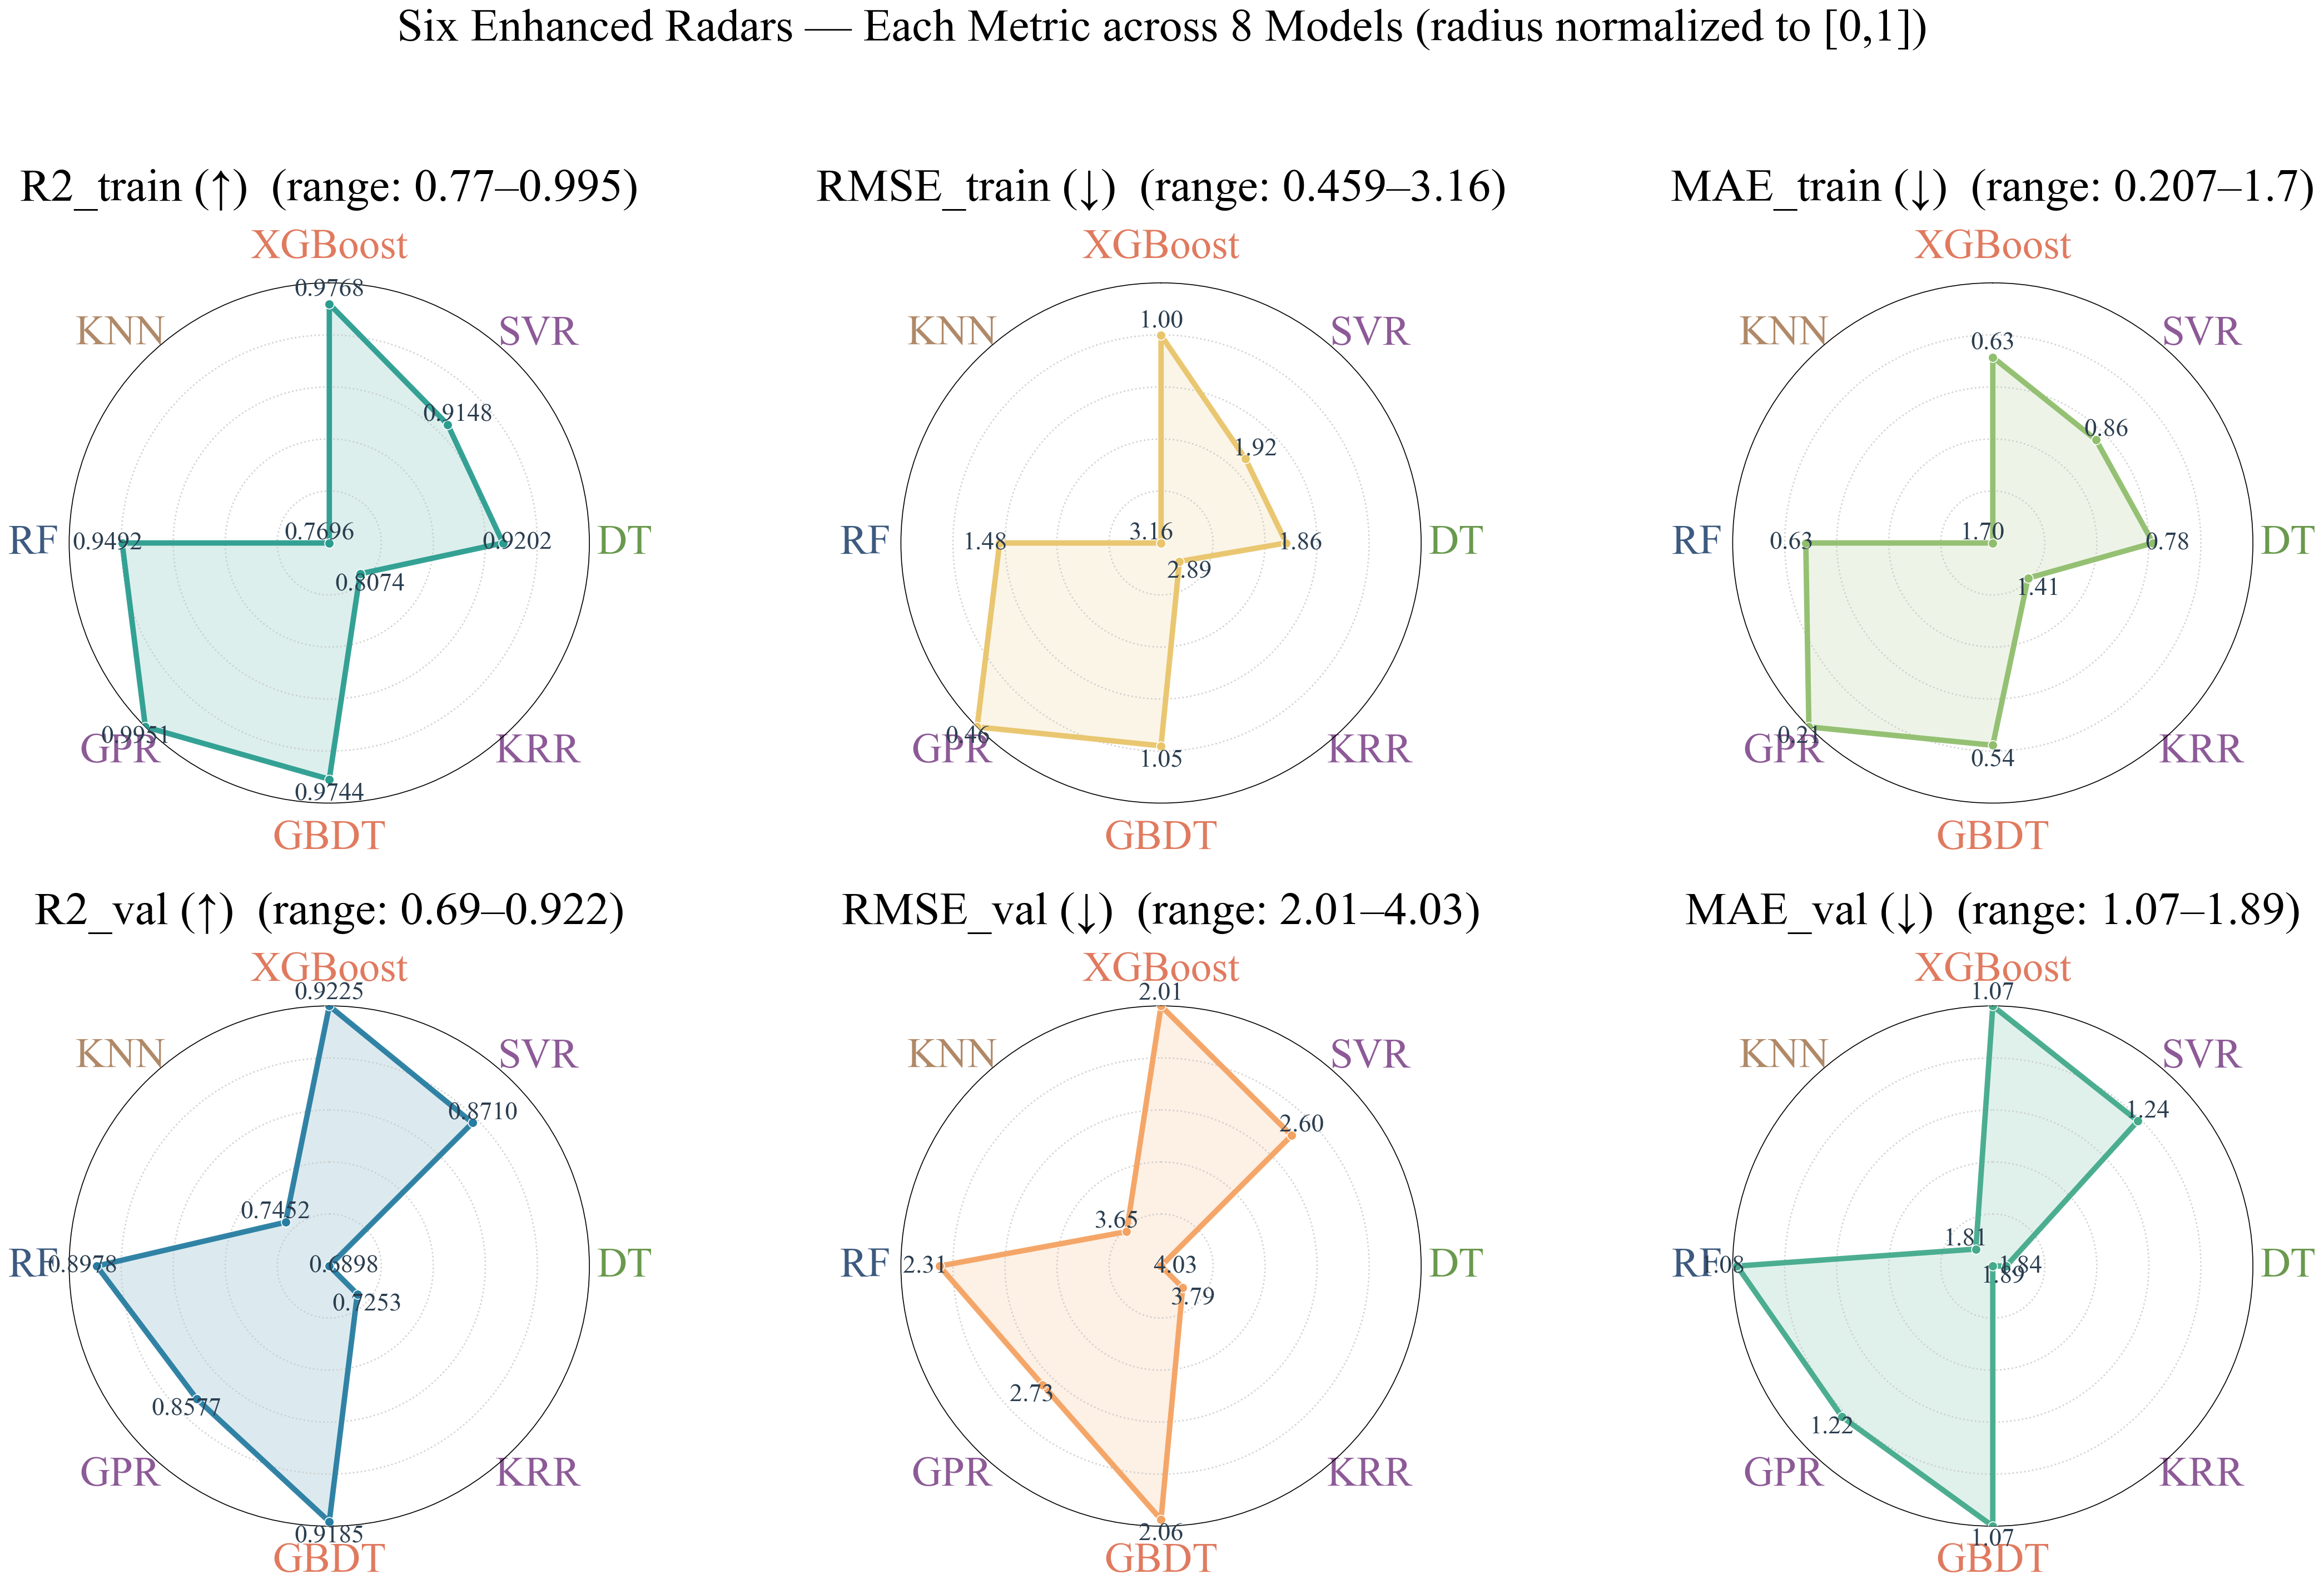

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

SCALE = 2.0

def fs(x):
    return int(round(x * SCALE))

rcParams.update({
    "figure.dpi": 150,
    "font.family": "Times New Roman",
    "font.size": fs(16),
    "axes.titlesize": fs(24),
    "axes.labelsize": fs(24),
    "xtick.labelsize": fs(24),
    "ytick.labelsize": fs(24),
    "figure.titlesize": fs(24),
    "legend.fontsize": fs(24),
})

rows = [
    ("XGBoost", 0.9768, 1.0019, 0.6340, 0.9225, 2.0123, 1.0679),
    ("SVR",     0.9148, 1.9208, 0.8623, 0.8710, 2.5967, 1.2410),
    ("DT",      0.9202, 1.8590, 0.7803, 0.6898, 4.0258, 1.8447),
    ("KRR",     0.8074, 2.8881, 1.4136, 0.7253, 3.7888, 1.8871),
    ("GBDT",    0.9744, 1.0528, 0.5392, 0.9185, 2.0634, 1.0677),
    ("GPR",     0.9951, 0.4589, 0.2075, 0.8577, 2.7267, 1.2152),
    ("RF",      0.9492, 1.4827, 0.6268, 0.8978, 2.3106, 1.0817),
    ("KNN",     0.7696, 3.1586, 1.6992, 0.7452, 3.6491, 1.8116),
]

df = pd.DataFrame(rows, columns=[
    "Model", "R2_train", "RMSE_train", "MAE_train", "R2_val", "RMSE_val", "MAE_val"
]).set_index("Model")

FAMILY = {
    "XGBoost": "Boosting",
    "GBDT": "Boosting",
    "RF": "Ensemble",
    "DT": "Tree",
    "SVR": "Kernel",
    "KNN": "Instance",
    "GPR": "Kernel(GP)",
    "KRR": "Kernel"
}

FAMILY_COLOR = {
    "Boosting": "#E07A5F",
    "Ensemble": "#3D5A80",
    "Tree": "#6A994E",
    "Kernel": "#8D5A97",
    "Kernel(GP)": "#8D5A97",
    "Instance": "#B08968"
}

USE_COLORED_LABELS = True
SHOW_VALUES = True
HIDE_RADIAL_TICK_VALUES = True

def norm_up(v):
    a, b = float(np.min(v)), float(np.max(v))
    return (v - a) / (b - a + 1e-12)

def norm_down(v):
    a, b = float(np.min(v)), float(np.max(v))
    return 1.0 - (v - a) / (b - a + 1e-12)

def format_value(title, val):
    if "R2" in title:
        return f"{val:.4f}"
    else:
        return f"{val:.2f}"

def draw_enhanced_radar(ax, models, raw_values, title, higher_is_better=True, color="C0"):
    L = len(models)
    angles = np.linspace(0, 2 * np.pi, L, endpoint=False)
    angles_closed = np.concatenate([angles, angles[:1]])

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    rad = norm_up(raw_values) if higher_is_better else norm_down(raw_values)
    rad_closed = np.concatenate([rad, rad[:1]])

    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    if HIDE_RADIAL_TICK_VALUES:
        ax.set_yticklabels([])
        ax.tick_params(axis="y", length=0)

    ax.yaxis.grid(True, ls=":", lw=max(0.8, 0.8 * SCALE * 0.8), color="#c9c9c9", alpha=0.85)
    ax.xaxis.grid(False)

    ax.plot(angles_closed, rad_closed, linewidth=2.6 * SCALE**0.85, color=color, alpha=0.95)
    ax.fill(angles_closed, rad_closed, color=color, alpha=0.16)
    ax.scatter(angles, rad, s=28 * (SCALE**1.2), color=color, edgecolor="white", linewidth=0.8, zorder=3)

    if SHOW_VALUES:
        for th, rr, val in zip(angles, rad, raw_values):
            ax.text(
                th,
                float(np.clip(rr + 0.055, 0.02, 1.05)),
                format_value(title, val),
                ha="center",
                va="center",
                fontsize=fs(11),
                color="#2b3e50",
                clip_on=False
            )

    tick_labels = []
    for m in models:
        if USE_COLORED_LABELS and m in FAMILY:
            tick_labels.append((m, FAMILY_COLOR.get(FAMILY[m], "#333333")))
        else:
            tick_labels.append((m, "#333333"))

    ax.set_thetagrids(angles * 180 / np.pi, [t for t, _ in tick_labels])
    ax.tick_params(axis="x", pad=fs(10))

    for lbl, (t, c) in zip(ax.get_xticklabels(), tick_labels):
        lbl.set_color(c)
        lbl.set_fontsize(fs(18))
        lbl.set_fontname("Times New Roman")

    ax.set_title(
        f"{title}  (range: {raw_values.min():.3g}–{raw_values.max():.3g})",
        pad=fs(12),
        fontsize=fs(20),
        fontname="Times New Roman"
    )

models = df.index.tolist()
metrics = [
    ("R2_train (↑)",   df["R2_train"].values,   True,  "#2a9d8f"),
    ("RMSE_train (↓)", df["RMSE_train"].values, False, "#e9c46a"),
    ("MAE_train (↓)",  df["MAE_train"].values,  False, "#90be6d"),
    ("R2_val (↑)",     df["R2_val"].values,     True,  "#277da1"),
    ("RMSE_val (↓)",   df["RMSE_val"].values,   False, "#f4a261"),
    ("MAE_val (↓)",    df["MAE_val"].values,    False, "#43aa8b"),
]

fig, axes = plt.subplots(2, 3, figsize=(15.2 * SCALE, 10.0 * SCALE), subplot_kw=dict(polar=True))
axes = axes.ravel()

for ax, (title, vals, up, col) in zip(axes, metrics):
    draw_enhanced_radar(ax, models, vals, title, higher_is_better=up, color=col)

fig.suptitle(
    "Six Enhanced Radars — Each Metric across 8 Models (radius normalized to [0,1])",
    y=0.995,
    fontsize=fs(20),
    fontname="Times New Roman"
)
fig.tight_layout(rect=[0, 0.03, 1, 0.97])

plt.show()